## Vinho Verde Wine Quality Analysis Notebook

___

### *Notebook by: [**Sofia French**](https://www.ncl.ac.uk/learning-and-teaching/digital-technologies/nula/guidance-and-support/find-my-students/)*
### *Student No.: **`230057999`***
### *Module No.: **`2034`***
___

## Table of contents
___
#### 1. [Introduction](#1-overview)
#### 3. [The Problem Domain](#)
___

## Introduction

___

This notebook is heavily inspired by [Randal S. Olson's](https://nbviewer.org/github/rhiever/Data-Analysis-and-Machine-Learning-Projects/blob/master/example-data-science-notebook/Example%20Machine%20Learning%20Notebook.ipynb#Required-libraries) notebook, as mentioned in the references and report. Specifically, much of the structure has helped me effectively tell my "data science story" in a clean and effective way! :)

File structure

___

## The Problem Domain
___

As outlined eloquently in the task description, I have been *"hired to consult for a winery in Portugal"* who wish to understand the truth behind the **quality disparity** in their **Vinho-Verde** wines.

Provided are three datasets, 

```
• winequality-red.csv
• winequality-white.csv
• winequality.names
```

The two `.csv` files include large data for red and white wines, with **4899** and **1600** data points respectively, and each contains data points with a set of 12 variables; 11 of which are physicochemical, with the last being the customers perceived quality.

My task is to create *"one or more models to predict quality given all other variables"*, in order for the winery to determine which properties of their wine are most influential to quality.

___

## The Datasets at a Glance
___

### Answering Olson's Questions 

[Randal S. Olson](https://nbviewer.org/github/rhiever/Data-Analysis-and-Machine-Learning-Projects/blob/master/example-data-science-notebook/Example%20Machine%20Learning%20Notebook.ipynb#Required-libraries) mentioned in his notebook, *"the first step to any data analysis project is to define the question or problem we're looking to solve, and to define a measure (or set of measures) for our success at solving that task"*. With that in mind, I examined the project and it's requirements using [Olson's](https://nbviewer.org/github/rhiever/Data-Analysis-and-Machine-Learning-Projects/blob/master/example-data-science-notebook/Example%20Machine%20Learning%20Notebook.ipynb#Required-libraries) questions:


> **Did you specify the type of data analytic question?**

I'm trying to predict the quality of Vinho Verde wines based on 11 properties, e.g. `acidity`, `sugar`, and `alcohol content`.
This is both an exploratory and predictive modelling problem. First, I'll need to explore and visualise how these features relate to a wines perceived quality. Then, I can build models to classify and regress the wine quality based on the most influential features.

> **Did you define the metric for success before beginning?**

It differs based on whether I'm using classification or regression, but both should use `k-fold cross validation`: in this project I will use **5-fold CV**.

For *classification* models:
1. F1-score
2. AUC
3. ROC
TBR

For *regression* models:
1. RMSE 
2. MAE
3. Related "error metrics"
TBR

For a model to be considered successful, it must outperform a base threshold (**the mean**) and generalise well across both red and white wines.

> **Did you understand the context for the question and the scientific or business application?**

I'm consulting for a winery in Portugal that produces Vinho Verde wines - red and white. They want to understand which factors most strongly determine wine quality so they can optimise the production process.

This analysis will inform the winery on which properties of wine should increase, decrease or remain constant during wine production in order to improve the quality of wines effectively (at least, I would assume, it's hard to get ahold of any stakeholders).

> **Did you record the experimental design?**

In both datasets, each record corresponds to a single wine. As mentioned in [The Problem Domain](#3-the-problem-domain), "the two datasets include 4899 and 1600 data points" where "each data point is a set of 12 variables; 11 of these are physicochemical measures, and the last is the perceived quality (sensory output)". 

> **Did you consider whether the question could be answered with the available data?**

The dataset is well suited for determining factors that influence wine quality. However, there are **limitations**:
- Quality is subjective to consumer
- There are likely other factors that influence quality that are not recorded

### Exploring the Datasets

Before I begin with the required tasks, as suggested in [Olson's](https://nbviewer.org/github/rhiever/Data-Analysis-and-Machine-Learning-Projects/blob/master/example-data-science-notebook/Example%20Machine%20Learning%20Notebook.ipynb#Required-libraries) notebook and hinted at in the [Canvas](https://ncl.instructure.com/courses/54995/pages/task-description-for-data-science?module_item_id=3344525), it's best to quickly check the data's sanity.  

Specifically, I'm checking for errors or unexpected qualities in either dataset. For this project, both datasets are well regarded and tested, meaning it is safe to assume the data is clean. However, for good practice, it can't hurt to double check.

To do this, I'll read both datasets into a pandas data frame (*df*) and display the first 5 records. First, the red wine dataset:

In [265]:
import pandas as pd

wine_red = pd.read_csv("../datasets/winequality-red.csv",sep=";")
wine_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


As expected, the data is loaded and populated. Now for white wine: 

In [266]:
wine_white = pd.read_csv("../datasets/winequality-white.csv",sep=";")
wine_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


Again, the dataset appears complete, with 12 fields and each as listed in the brief. No problems here.

Next, starting again with red wine, I'll use pandas `describe` to examine two different key fields: `alcohol` and `residual sugar`.

In [267]:
wine_red[["alcohol", "residual sugar"]].describe()

,alcohol,residual sugar
count,1599.000000,1599.000000
mean,10.422983,2.538806
std,1.065668,1.409928
min,8.400000,0.900000
25%,9.500000,1.900000
50%,10.200000,2.200000
75%,11.100000,2.600000
max,14.900000,15.500000


Focusing first on `alcohol`:
- It has a good range, with the `min` value at `8.4` and `max` value at `14.9`.
- This makes it clear why later separating into a three valued variable `alcohol_cat`, with *low, mid, and high* values would be beneficial - there is sufficient spread to justify three levels.

Next on `residual sugar`:
- It appears most red wines are dry as the mean is approximately `3`.
- The data is skewed heavily to the right tail, as some outlier values have residual sugars as high as `15.5`.
- This makes it clear why a binary value splitting the sweetness evenly (`isSweet`) would be beneficial when examining this feature.

**Moving onto white wine**, I'll perform the same analysis.

In [268]:
wine_white[["alcohol", "residual sugar"]].describe()

,alcohol,residual sugar
count,4898.000000,4898.000000
mean,10.514267,6.391415
std,1.230621,5.072058
min,8.000000,0.600000
25%,9.500000,1.700000
50%,10.400000,5.200000
75%,11.400000,9.900000
max,14.200000,65.800000


Focusing first on `alcohol`:
- Very similar to red wine, however white wines have a slightly higher mean (`10.51...` vs. `10.42...`).
- Spread is also larger than red (std as `1.23...` vs. `1.07...`).
- But again, this is a well distributed variable and thus supports separating into a three valued `alcohol_cat` variable.

Next on `residual sugar`:
- Much higher mean than in the red wine dataset (mean = `6.39...` vs. `2.54...`).
- The max value (`65.8`) is an extreme outlier.
- Again, the distribution is very right tail heavy, though much more so than with the red wines.
- The mean (`6.39...`) again suggests many dry wines and a lower quantity of sweet wines.

#### First Conclusions

For both datasets:
- In the later analysis with the `alcohol_cat` category, it would make sense to split into three values as both datasets have good spread (between `min` and `max` valued.)
- In the later analysis with the `isSweet` category, it would make sense to split on the median value to avoid a lack of high sweetness wines and a large amount of dry wines.

Since both datasets seem initially OK, I'll now create a data frame to contain them for later plotting and analysis, and store the colours and palettes for combined plots.

In [269]:
wine_red["type"] = "red"
wine_white["type"] = "white"
wine_all = pd.concat([wine_red, wine_white])

palette_red_white = {"red": "#d62728", "white": "#1f77b4"}

#### First Plots

Before I explore the two fields any further, in preparation for both initial and later plots, I'll import my chosen libraries: `matplotlib` and `seaborn`. 

Both were chosen over the other mentioned alternative, `Altair` for the same reasons:
1. Simpler
2. More tutorials
3. More common
4. I've used `matplotlib` before

This project uses an array of new techniques and, as highlighted in my *reflective log*, is a learning curve for me in many respects so I felt it best to choose tools that are well documented and somewhat familiar me.

In [270]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb

# Set style
sb.set_theme(style="whitegrid", font_scale=1.2)
palette_red = sb.color_palette("Reds", n_colors=9)
palette_white = sb.color_palette("Blues", n_colors=9)

Next, I generated a scatterplot matrix for both datasets. 

This was suggested in [Olson's](https://nbviewer.org/github/rhiever/Data-Analysis-and-Machine-Learning-Projects/blob/master/example-data-science-notebook/Example%20Machine%20Learning%20Notebook.ipynb#Required-libraries) notebook as a tool to quickly check for errors or anomalies.

Originally, I compared every category against `quality`, but the 121 generated scatterplots were too busy for me to gain any insight from. Instead, for a quick initial look, I compare `alcohol`, `volatile acidity`, `sulphates`, `citric acid` against eachother with the colours of the points representing `quality` from a scale, for reds, of 3 -> 8.

I saved all the generated figures for this project in the directory `figures/`. For more information, see [Introduction](#1-introduction) where I explain the file structure.

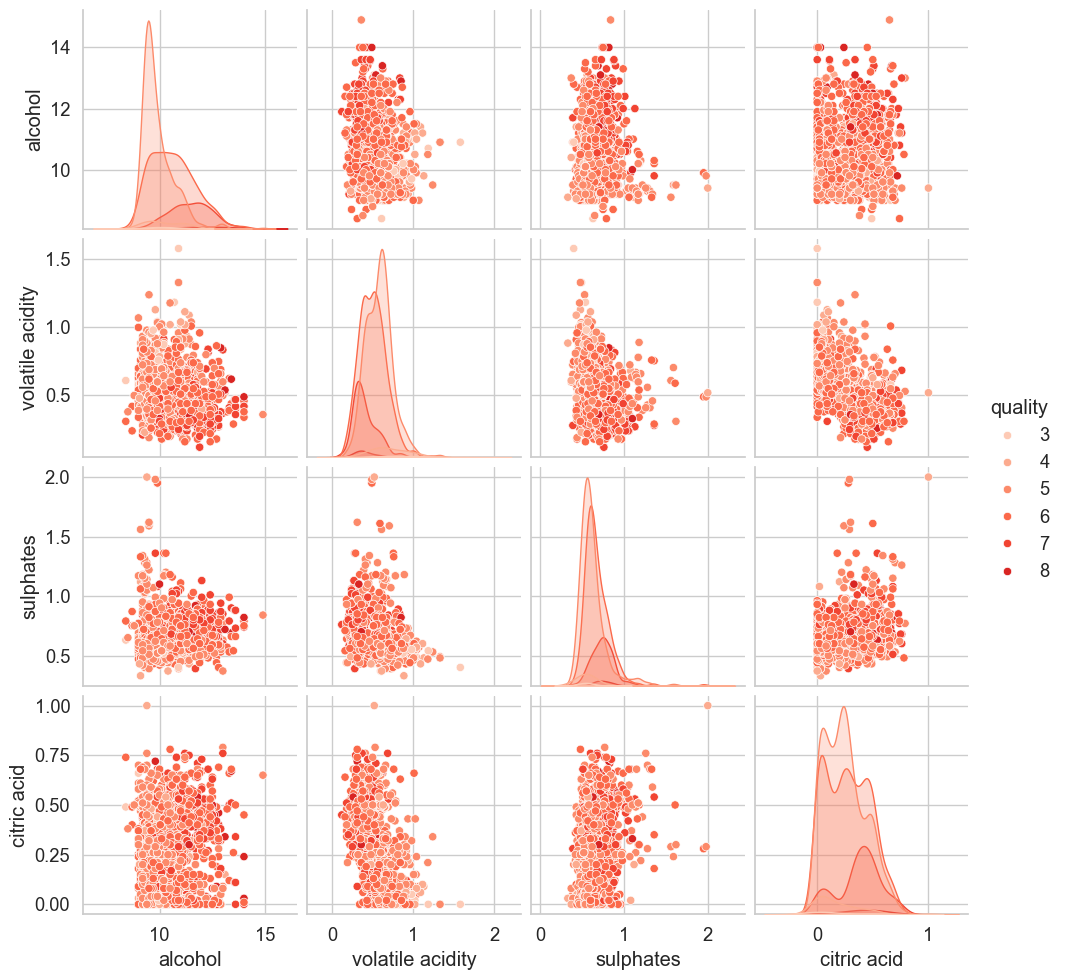

In [271]:
sb.pairplot(
    wine_red[["alcohol", "volatile acidity", "sulphates", "citric acid", "quality"]],
    hue="quality",
    palette=palette_red[1:7]
    )
plt.savefig("../figures/init_scatterplot_red")

#### Observations

A quick look at patterns in these plots suggests:

**For `Alcohol`**:
- In every plot (excluding `volatile acidity`) where `alcohol` is compared, higher quality wines (6 -> 8) tend to have higher alcohol content.
- The KDE plot shows that low quality wines peak at **low alcohol levels**, whereas high quality wines peak around **12**

**For `Volatile Acidity`**
- The trend is the opposite to `alcohol`. Higher `volatile acidity` appears to cause lower quality wine.
- Wines with qualities 3 -> 4 cluster at higher values of `volatile acidity`.

**For `Sulphates`**
- There's a slight pattern with high quality wines having slightly higher sulphates, but not strongly enough to apply causation based on the limited plots.

**For `Citric Acid`**
- Hard to interpret — there’s no obvious relationship and dots are scattered evenly.

#### First Plot Conclusions

- **Alcohol** appears to be strongly correlated with better quality wines, as is the most predictive feature out of the 4 I plotted and interpreted.
- **Volatile acidity** is negatively correlated with quality.
- **Sulphates** may be slightly positively correlated with quality.
- **Citric acid** may not be a strong predictor.

Now lets examine the ***white wine dataset***.

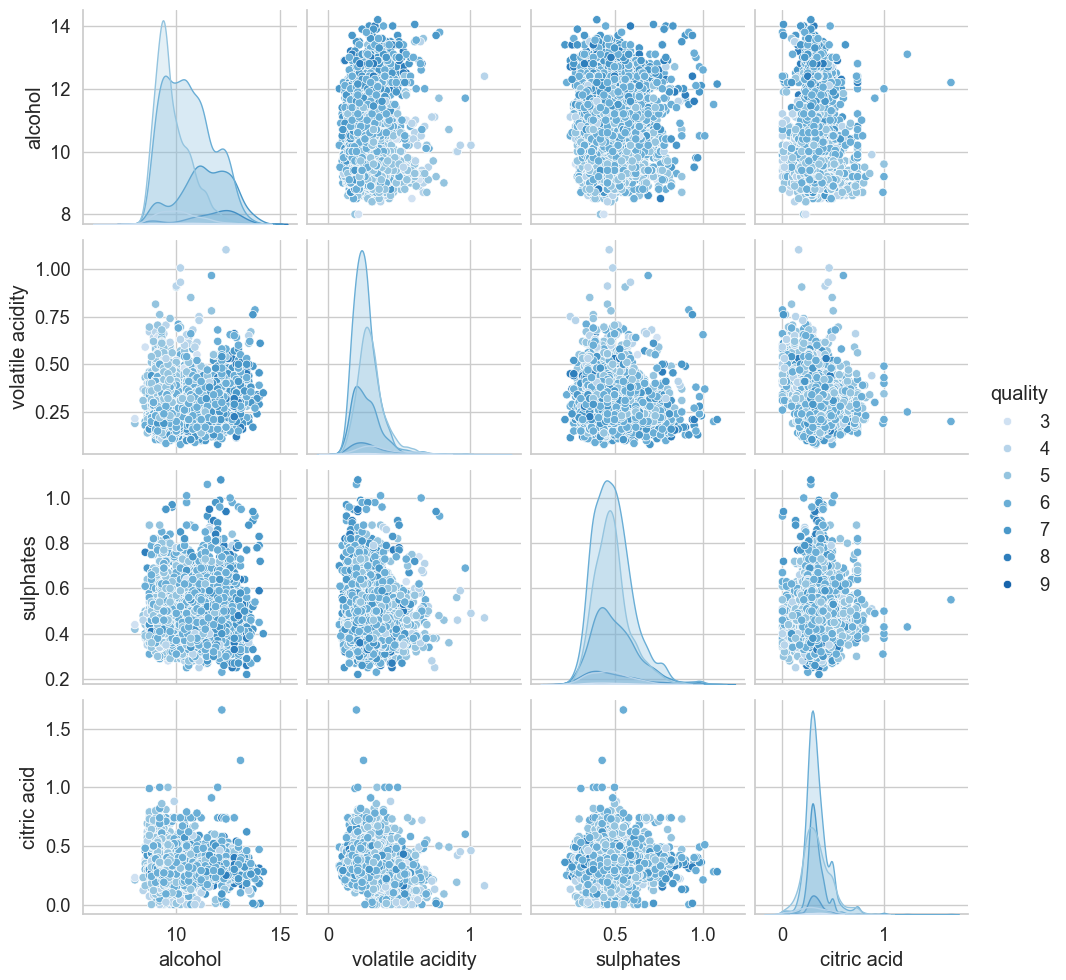

In [272]:
sb.pairplot(
    wine_white[["alcohol", "volatile acidity", "sulphates", "citric acid", "quality"]],
    hue="quality", 
    palette=palette_white[1:8]
    )
plt.savefig("../figures/init_scatterplot_white")

#### Observations

A quick look at patterns here suggests:

**For `Alcohol`**:
- Just like in red wine: higher alcohol tends to mean higher quality.
- The KDE plot shows highest quality 8 -> 9 wines peak again around the value **12**.

**For `Volatile Acidity`**
- Less dramatic than in red wine, but still: higher volatile acidity tends to mean lower quality.
- Quality 3 -> 5 values are slightly more concentrated at higher values.

**For `Sulphates`**
- Again, there's some separation: quality 8 -> 9 wines tend to have slightly higher sulphates.
- Distribution is tighter than in red wine.

**For `Citric Acid`**
- Similar to red: no obvious relationship with quality.
- KDE shows distributions are nearly overlapping across all quality levels.

#### First Plot Overall Conclusions

- **Alcohol** is a strong predictor of quality in both red and white wines.
- **Volatile acidity** is weakly negatively correlated with quality — maybe not as useful as in red wine.
- **Sulphates** again may have slight positive association, but not dramatically.
- **Citric acid** are probably not worth prioritising for later modelling.

### Data Integrity Assumption

[Olson's](https://nbviewer.org/github/rhiever/Data-Analysis-and-Machine-Learning-Projects/blob/master/example-data-science-notebook/Example%20Machine%20Learning%20Notebook.ipynb#Required-libraries) notebook has other steps before exploring his dataset, including **tidying** and **unit testing** the data. 

I have chosen to skip these steps for a few reasons:
- The red and white wine datasets used in this project are widely recognised benchmark datasets sourced from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/186/wine+quality). 
- They are commonly used datasets for supervised learning and regression techniques.

And given the fact that they contain:
- No missing values
- Well formatted numeric features
- Consistent structure across both datasets

There is no need for extensive data cleaning or validation. I will, however, apply minimal stripping to each column to ensure consistency when referencing variables.
___

In [273]:
wine_red.columns = wine_red.columns.str.strip()
wine_white.columns = wine_white.columns.str.strip()

## Task 1: Exploratory Analysis

___

Now the data has been *loaded*, *checked*, *plotted* and *stripped*, it's time to move onto the required tasks. Briefly, for Task 1, the requirements are:

1. (A) Plot and compare the distribution of wine `quality` for red and white wines.

2. (B) Create a 3 level `alcohol_cat` variable (low, mid, high) based on `mean` +- `stddev`.

3. (C) Analyse and plot wine quality distribution by `alcohol` category to assess its impact on quality.

4. (D) Create a binary `isSweet` variable by choosing a `residual sugar` threshold (likely the `mean`) that balances the classes.
TBR

5. (E) Compare wine quality distributions for sweet vs dry wines to see if sweetness affects perceived quality.

### Task 1A: Plot Wine Quality Distribution

To begin, I'll start with Task 1A: plotting and comparing how wine quality differs between red and white wines. For this, I'll first use a box plot, as `quality` is discrete, and then a violin plot to examine the effect of the distributions of the classes.

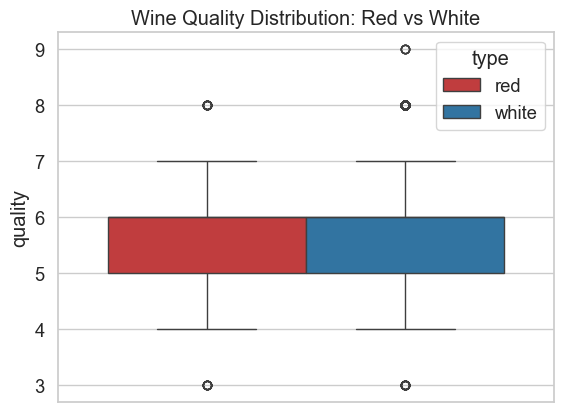

In [274]:
sb.boxplot(
    hue="type", 
    y="quality", 
    data=wine_all, 
    palette=palette_red_white
    )
plt.title("Wine Quality Distribution: Red vs White")
plt.savefig("../figures/task1a_wine_quality_distribution_both_box")
plt.show()

#### Box Plot Observations

In the box plot above, for red and white wines:

| **Statistic**         | **Red Wine** | **White Wine** |
| :---------------- | :------: | :--------: |
| Median            |   5-6    |    5-6     |
| IQR               |   5-6    |    5-6     |
| Range             |   4-7    |    4-7     |
| Outliers          |   3,8    |   3,8,9    |


Upon examining **both**, a few things are noticeable:
- Central tendency is the same — both reds and whites cluster around a median of `6`.
- Spread is nearly identical — the IQR is the same for both.
- White wines show a slightly longer upper tail — suggesting that very high-quality white wines (`8`–`9`) are slightly more common than reds.
- Outliers are symmetric and minimal.

#### Box Plot Conclusion

White and red wines have very similar quality distributions, but white wines may have a slightly higher upper potential for quality.

#### Violin Plot

Now lets plot the same data but this time using a **violin plot**.



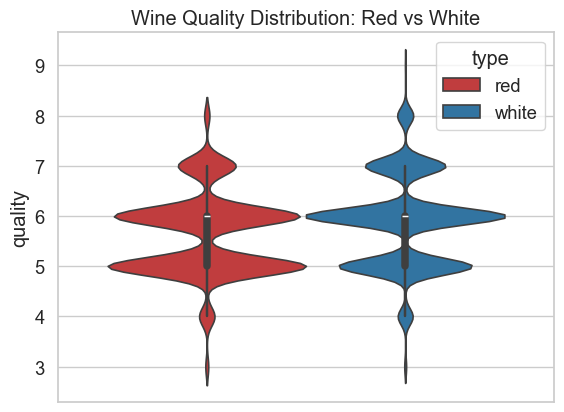

In [275]:
# Plot violin
sb.violinplot(
    hue="type",
    y="quality",
    data=wine_all,
    palette=palette_red_white,
    inner="box",
    linewidth=1.2
)

plt.title("Wine Quality Distribution: Red vs White")
plt.savefig("../figures/task1a_wine_quality_distribution_both_violin")
plt.show()

#### Violin Plot Observations

In the box plot above, for red and white wines:
- The mode for *both* datasets is `6`, with `5` and `6` similarly popular qualities for red wine.
- Along the same lines, red wines show stronger peaks at quality 5 and 6, indicating tighter clustering.
- White wines have more spread between `5` and `7`, and higher density at `7` and `8`, especially visible in the wider top of the blue violin.
- A tiny peak at `3` is visible for red wine, but not for white.

#### Violin Plot Conclusion

White and red wines have very similar quality distributions, but white wines have a slightly larger distribution for high quality wines.

### Task 1B: Discretise Alcohol Content

Next is Task 1B: *"Discretise the alcohol content variables (separately for whites and reds) into low, mid, high based on its distribution"*.

To complete this task, following the description, I need a three valued variable `alcohol_cat` that represents:

- **low** alcohol < (`mea` - `stddev`)
- (`mean` - `stddev`) < **mid** alcohol < (`mean` + `stddev`)
- **high** alcohol > (`mea`n + `stddev`)

This is shown below:

In [276]:
def add_alcohol_category(df):
    """
    Adds an `alcohol_cat` column to the passed data frame based on alcohol content.

    The alcohol content is discretised into three categories:

    - `low`  if `alcohol` < (`mean` - `stddev`)
    - `mid`  if `alcohol` is in one `stddev` of the mean
    - `high` if `alcohol` > (`mean` + `stddev`)

    Parameters:
        df (pd.DataFrame): A pandas data frame.

    Returns:
        pd.DataFrame: The passed data frame with an added `alcohol_cat` column.
    """
    mean = df["alcohol"].mean()
    stddev = df["alcohol"].std()
    
    def discretise(alcohol):
        if alcohol < mean - stddev:
            return "low"
        elif alcohol > mean + stddev:
            return "high"
        else:
            return "mid"
    
    return df.assign(alcohol_cat=df["alcohol"].apply(discretise))

Now to apply to the data frames, including the combined dataset.

In [277]:
wine_red = add_alcohol_category(wine_red)
wine_white = add_alcohol_category(wine_white)
wine_all = add_alcohol_category(wine_all)

### Task 1C: Discretise Alcohol Content

Now there is a discrete alcohol category, I can begin plotting.

Task1C states: *"Describe the distribution of wine quality as in (1.A), but separately for low-, mid-, and high-alcohol content."*. As I am comparing the distribution of how alcohol affects wine quality, I should again draw box plots to compare and check peaks and mode with a violin plot.

I'll start again using box plots, with red wine first.

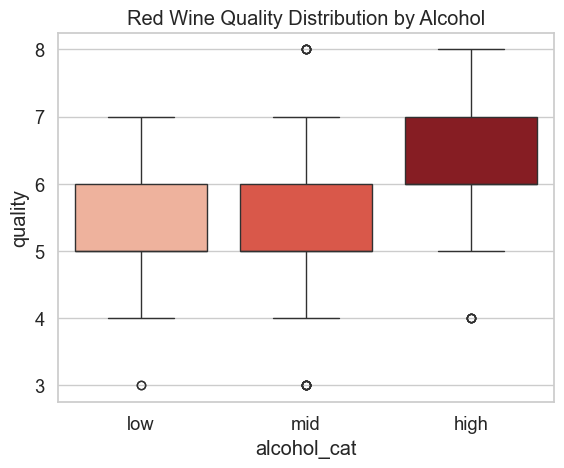

In [278]:
sb.boxplot(
    x="alcohol_cat", 
    hue="alcohol_cat",
    y="quality", 
    data=wine_red, 
    palette={
        "low": palette_red[2],
        "mid": palette_red[5],
        "high": palette_red[8]
        },
    order=["low", "mid", "high"],
    hue_order=["low", "mid", "high"],
    )
plt.title("Red Wine Quality Distribution by Alcohol")
plt.savefig("../figures/task1c_wine_quality_distribution_by_alc_box_red")
plt.show()

#### Box Plot Observations

In the box plot above, for **red wines**:

| **Statistic**     |   `low`    |   `mid`    |  `high`   |
| :---------------- | :------: | :------: | :------: |
| Median            |   5-6    |   5-6    |   6-7    |
| IQR               |   5-6    |   5-6    |   6-7    |
| Range             |   4-7    |   4-7    |   5-8    |
| Outliers          |    3     |   3,8    |    4     |


The boxplot for **red wine** quality by alcohol shows:
- Median quality increases from `low`/`mid` -> `high` alcohol.
- `low` and `mid` categories have very similar spread (IQR), but `high` alcohol wines have a higher spread (IQR).
- Outliers at both small (3) and large (8) quality extremes are rare.

#### Box Plot Conclusion

White and red wines have very similar quality distributions, but white wines may have a slightly higher upper potential for quality.

#### Next

Now lets plot the same data but this time for ***white wine***.

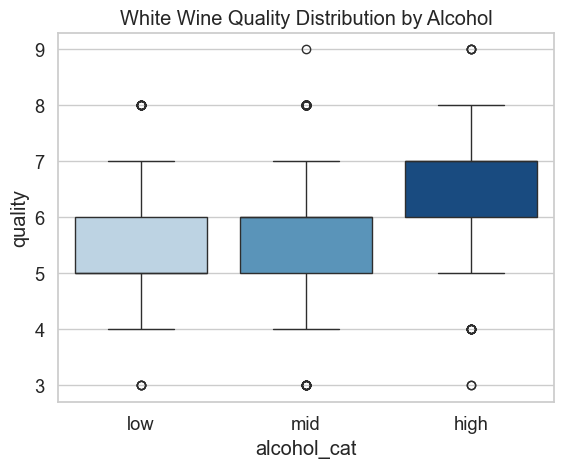

In [279]:
sb.boxplot(
    x="alcohol_cat", 
    hue="alcohol_cat", 
    y="quality", 
    data=wine_white, 
    palette= {
        "low": palette_white[2],
        "mid": palette_white[5],
        "high": palette_white[8]
        },
    order=["low", "mid", "high"],
    hue_order=["low", "mid", "high"],
    )
plt.title("White Wine Quality Distribution by Alcohol")
plt.savefig("../figures/task1c_wine_quality_distribution_by_alc_box_white")
plt.show()

#### Box Plot Observations

In the box plot above, for **white wines**:

| **Statistic**     |   `low`    |   `mid`    |  `high`   |
| :---------------- | :------: | :------: | :------: |
| Median            |   5-6    |   5-6    |   6-7    |
| IQR               |   5-6    |   5-6    |   6-7    |
| Range             |   4-7    |   4-7    |   5-8    |
| Outliers          |   3,8    |  3,8,9   |  3,8,9   |


The boxplot for **white wine** quality is very close to red wines':
- Median rises from `low` -> `high`.
- `high` alcohol group has a higher IQR (6–7) vs `low`/`mid` (5–6)
- More outliers overall, especially higher values (9s in `high` alcohol)

#### Box Plot Conclusion

White wines also show a positive relationship between alcohol content and quality, maybe slightly stronger than reds.

#### Next

Now lets plot for red and white again, this time using violin plots. I'll start with red.

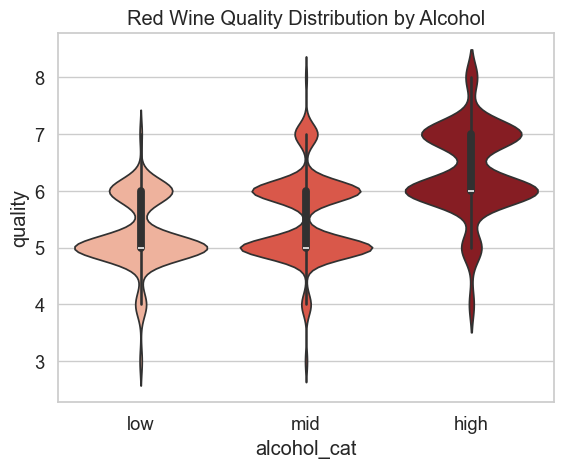

In [280]:
sb.violinplot(
    x="alcohol_cat", 
    hue="alcohol_cat", 
    y="quality", 
    data=wine_red, 
    palette= {
        "low": palette_red[2],
        "mid": palette_red[5],
        "high": palette_red[8]
        },
    order=["low", "mid", "high"],
    hue_order=["low", "mid", "high"],
    )

plt.title("Red Wine Quality Distribution by Alcohol")
plt.savefig("../figures/task1c_wine_quality_distribution_by_alc_vi_red")
plt.show()

#### Violin Plot Observations

In the plot above, for **red wines**:
- The density clusters confirm the box plot: peaks for low and mid are at quality 5–6, but for high, it's 6–7.
- `high` category has visibly thicker (thus more) better quality wines, with many higher quality wines (7–8).

#### Violin Plot Conclusion

The violin plot supports my analysis of the box plot — high alcohol red wines skew toward higher quality ratings.

For the ***white wines***:

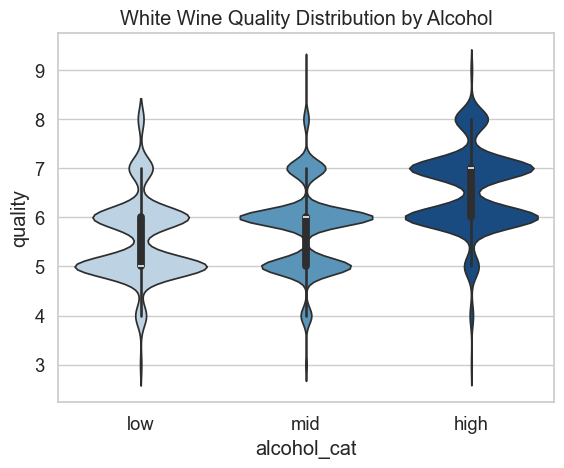

In [281]:
sb.violinplot(
    x="alcohol_cat",
    hue="alcohol_cat", 
    y="quality", 
    data=wine_white, 
    palette= {
        "low": palette_white[2],
        "mid": palette_white[5],
        "high": palette_white[8]
        },
    order=["low", "mid", "high"],
    hue_order=["low", "mid", "high"],
    )

plt.title("White Wine Quality Distribution by Alcohol")
plt.savefig("../figures/task1c_wine_quality_distribution_by_alc_vi_white")
plt.show()

#### Violin Plot Observations

In the plot above, for **white wines**:
- The distribution is broader than red wine, but the same trend is visible - positive correlation between alcohol content and quality.
- `low` and `mid` cluster around `quality` 5–6
- `high` alcohol has a fatter top end, with more density at 7–8

#### Violin Plot Conclusion

In white wines, high alcohol again correlates with higher quality, and there’s more visible upward skew in the high group.

#### Overall

Both red and white wines show a clear positive association between alcohol content and quality.
Wines in the high alcohol category consistently have higher medians, higher peaks, and more high end outliers.

**For Later Modelling** the consistant correlaton of alcohol content to quality suggests the alcohol feature could be **useful in both regression and classification models**.


### Task 1D

Now task 1C is complete, I'll move onto task 1D - *"plot the residual sugar variable and identify a suitable threshold to separate 'sweet' from 'dry' wines"* using an *"isSweet"* binary variable.

#### `isSweet`

As seen in my earlier analysis, [Exploring the Dataset](#exploring-the-datasets), the distribution of residual sugar is **skewed** for both red and white wines. So, to examine it's affect on quality, I'll need to split the data evenly.

To do this, each record will be classified with an `isSweet` value of:

- `1`, if residual sugar >= median,
- `0`, if residual sugar <= median.

Using the **median** means there will be an almost even split between sweet and dry, providing **balanced groups** with approximately the same amount of records.

In [282]:
def add_isSweet(df):
    """
    Adds binary 'isSweet' column to the data frame based on residual sugar levels.

    The function uses the median of the `residual sugar` column as a threshold to
    split wines into two, balanced categories:
    - 0 if (`residual sugar` <= `median`)
    - 1 if (`residual sugar` >= `median`)

    Parameters:
        df (pd.DataFrame): A pandas data frame containing a `residual sugar` column.

    Returns:
        pd.DataFrame: The original data frame with an added `isSweet` column.
    """
    threshold = df["residual sugar"].median()
    return df.assign(isSweet=(df["residual sugar"] >= threshold).astype(int))

And apply to all data frames:

In [283]:
wine_all = add_isSweet(wine_all)
wine_red = add_isSweet(wine_red)
wine_white = add_isSweet(wine_white)

The task (*1D*) states: *"find a threshold such that each class has approximately the same number of records"*. The median should provide an even threshold, but to check:

In [284]:
isSweet_data_split = pd.DataFrame({
    "All Wines": wine_all["isSweet"].value_counts(normalize=True),
    "Red Wines": wine_red["isSweet"].value_counts(normalize=True),
    "White Wines": wine_white["isSweet"].value_counts(normalize=True),
})
isSweet_data_split.index = ["Dry (0)", "Sweet (1)"]
isSweet_data_split

,All Wines,Red Wines,White Wines
Dry (0),0.503309,0.529706,0.501837
Sweet (1),0.496691,0.470294,0.498163


It works - each data frame has been split approximately evenly. That's **task 1D** complete!

### Task 1E: Plotting against `isSweet`

Now I'll begin **task 1E**: *"repeat the distribution analysis"* of quality, this time with quality vs `isSweet`. Again, as I am comparing the distribution of how sweetness affects quality, I use box plots and violin plots.

I'll start again with box plots, red wine first:

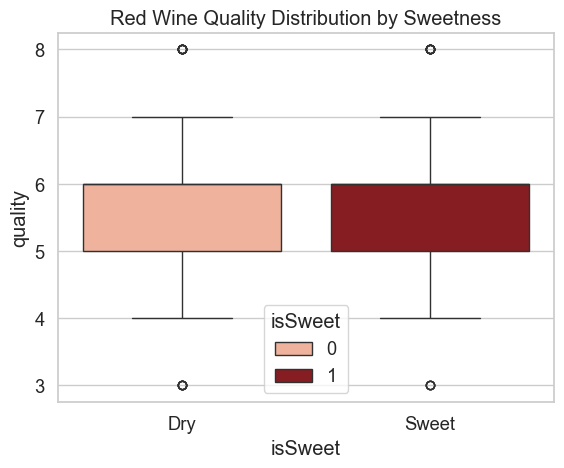

In [285]:
sb.boxplot(
    x="isSweet", 
    y="quality", 
    hue="isSweet",
    data=wine_red, 
    palette={
        0: palette_red[2],
        1: palette_red[8]
    },
)
plt.title("Red Wine Quality Distribution by Sweetness")
plt.xticks([0, 1], ["Dry", "Sweet"])
plt.savefig("../figures/task1E_wine_quality_distribution_by_isS_box_red")
plt.show()

#### Box Plot Observations

In the box plot above, for **red wines**:

| **Statistic**     |  `dry`   | `sweet`  |
| :---------------- | :------: | :------: |
| Median            |   5-6    |   5-6    |
| IQR               |   5-6    |   5-6    |
| Range             |   4-7    |   4-7    |
| Outliers          |   3,8    |   3,8    |


The boxplot for **red wine** quality by `isSweet` shows:
- Medians for dry and sweet wines are identical (5/6).
- IQR is also the same (5 to 6).
- Whiskers extend equally (4 to 7)
- Some rare outliers at 3 and 8

#### Box Plot Conclusion

Sweet and dry red wines show no meaningful difference in quality. The distribution is visually identical, suggesting sweetness does not impact red wine quality in this dataset.

#### Next

Now I'll plot the same data but this time for ***white wine***.

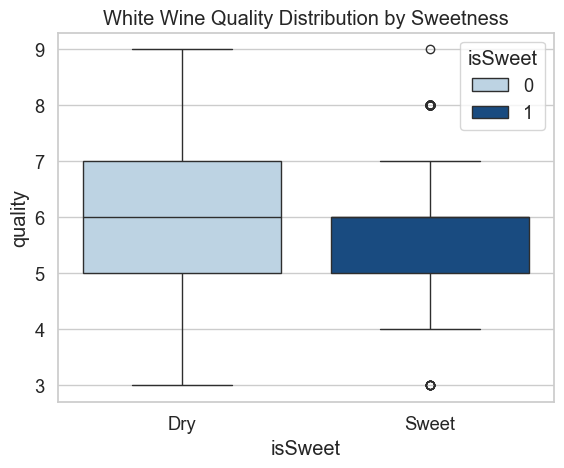

In [286]:
sb.boxplot(
    x="isSweet", 
    y="quality", 
    hue="isSweet",
    data=wine_white, 
    palette={
        0: palette_white[2],
        1: palette_white[8]
    },
)
plt.title("White Wine Quality Distribution by Sweetness")
plt.xticks([0, 1], ["Dry", "Sweet"])
plt.savefig("../figures/task1E_wine_quality_distribution_by_isS_box_white")
plt.show()

#### Box Plot Observations

In the box plot above, for **white wines**:

| **Statistic**     |  `dry`   | `sweet`  |
| :---------------- | :------: | :------: |
| Median            |    6     |   5-6    |
| IQR               |   5-7    |   5-6    |
| Range             |   3-9    |   4-7    |
| Outliers          |    -     |  3,8,9   |


The boxplot for **white wine** quality by `isSweet` shows:
- Dry wines have a higher median (dry is at 6 vs ~5.5 for sweet wines).
- Dry wines show a broader upper range, with qualities as high as 9.
- Sweet wines are more concentrated between 5–6, with fewer high quality outliers.
- Outliers above 7 are more common in dry white wines.

#### Box Plot Conclusion

Dry white wines are generally higher quality than sweet ones. There's a small but clear shift in distribution toward higher scores for dry wines, including more outliers at quality 8–9.

Overall, the box plots suggest sweetness does not affect quality in red wine, but dry white wines tend to be rated higher than sweet white wines.

#### Next

Now to compare these findings against violin plots. 

Red wine first:

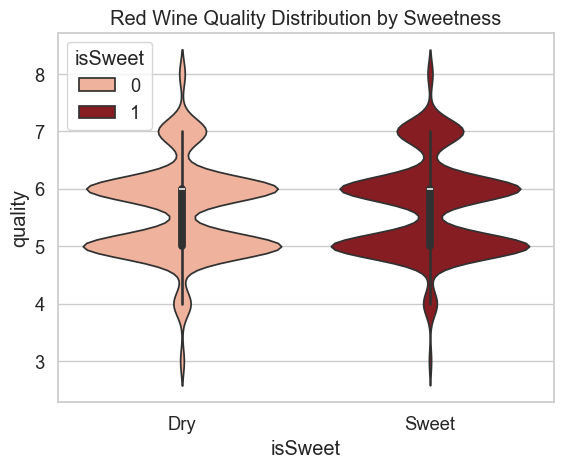

In [287]:
sb.violinplot(
    x="isSweet", 
    hue="isSweet", 
    y="quality", 
    data=wine_red, 
    palette= {
        0: palette_red[2],
        1: palette_red[8]
        },
    )

plt.title("Red Wine Quality Distribution by Sweetness")
plt.xticks([0, 1], ["Dry", "Sweet"])
plt.savefig("../figures/task1E_wine_quality_distribution_by_isS_vi_red")
plt.show()

#### Violin Plot Observations

In the plot above, for **red wines**:
- Distribution shapes for dry and sweet reds are nearly identical.
- Both groups show peaks at quality 5 and 6, with thinner tails toward 4 and 7.
- The median and spread are once again visually identical.

#### Violin Plot Conclusion

In red wines, sweetness has no clear effect on perceived quality. The violin plot confirms what the box plot showed — the distributions are hard to tell apart and almost symmetrical.

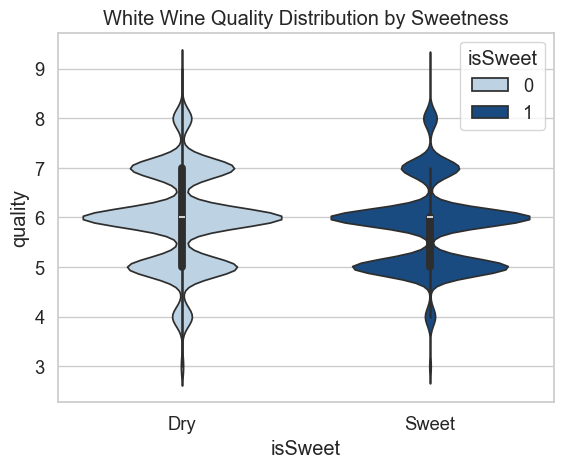

In [288]:
sb.violinplot(
    x="isSweet", 
    hue="isSweet", 
    y="quality", 
    data=wine_white, 
    palette= {
        0: palette_white[2],
        1: palette_white[8]
        },
    )

plt.title("White Wine Quality Distribution by Sweetness")
plt.xticks([0, 1], ["Dry", "Sweet"])
plt.savefig("../figures/task1E_wine_quality_distribution_by_isS_vi_white")
plt.show()

#### Violin Plot Observations

In the box plot above, for **red wines**:
- Dry white wines have a wider top half — more wines rated 7 and above.
- Sweet white wines show density tightly concentrated around quality 5–6, with fewer high-end values.

#### Violin Plot Conclusion

In white wines, dry wines are more often rated higher than sweet ones. This violin plot makes the skew toward higher quality for dry whites and supports the previous box plot.

#### Overall

Violin plots supported my box plot analysis that white wine sweetness affects perceived quality, but red wine sweetness does not.

**For Later Modelling:** 
- The lack of correlaton of sweetness to quality suggests the `isSweet` feature would be **unhelpful in later models for red wine quality**
- The correlation between dry wines and higher quality could be a helpful predictor in **white wines quality** modelling.

___

## Task 2: Variable Analysis
___

For **task 2**, the description reads: *"try and determine which subset of your variables can be most useful for learning"*. 

To do this, it suggests:
- Analysing each pair of variables
- Analysing each variable and the quality outcome
- Producing a visual representation in the form of a Correlation Matrix

### Correlation Methods

Comparing the 3 suggested metrics, `pearson`, `kendall`, `spearman`:

| Method | Description | Use when |
|:------|:------|:------|
| **Pearson** | Measures linear correlations | Data is continuous and linear |
| **Spearman** | Measures monotonic (rank-based) correlation | Relationships may be non linear but ordered |
| **Kendall**  | Measures concordance between ranked pairs | Small datasets or need for "robustness" |

#### Justification for `Spearman`

In this project, I chose to use `spearman` correlation because:
- Wine quality is a **discrete variable** (measured from range 3–9)
- Many features (e.g. alcohol, acidity) may have **non linear** but **monotonic** relationships with quality
- `spearman` handles these cases better than `pearson`, which assumes all relationships are linear
- The datasets are large

Thus `spearman` is the most appropriate choice for the correlation analysis.

### Predictions:

Based on the previous analysis, I predict:
- Alcohol content will be a strong indicator of quality
- Sweetness will be a strong indicator of quality for **white wines**

Below, I'll define the correlation matrix first for each dataset:

In [289]:
spearman_cm_red = wine_red.corr(numeric_only=True, method='spearman')
spearman_cm_white = wine_white.corr(numeric_only=True, method='spearman')

Then, I'll first plot the matrix for red wines:

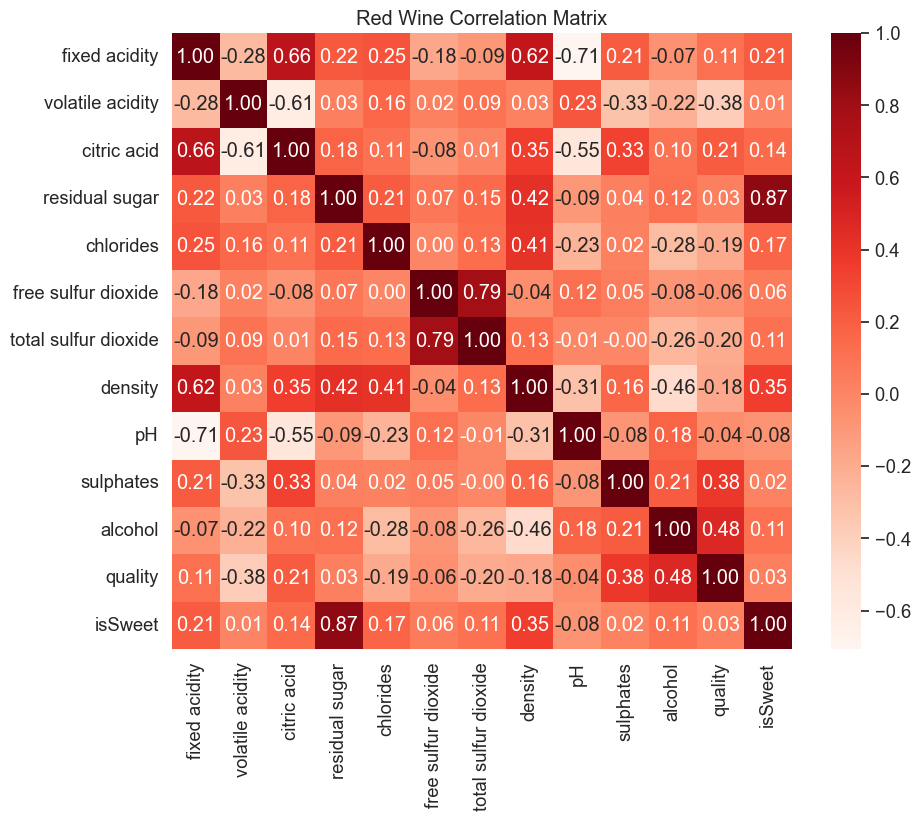

In [290]:
plt.figure(figsize=(10, 8))
sb.heatmap(spearman_cm_red, annot=True, cmap="Reds", fmt=".2f")
plt.title("Red Wine Correlation Matrix")
plt.savefig("../figures/task2_correlation_matrix_red.png")
plt.show()

#### Red Wine Variable Correlations

For red wine, the most prominent feature relationships in comparison to quality are:

| Top Features      | Correlation with `quality` |
|:-----------------:|:--------------------------:|
| `alcohol`         |         **0.48**           |
| `sulphates`       |         **0.38**           |
| `volatile acidity`|        **-0.38**           |
| `citric acid`     |         **0.21**           |
| `total sulfur dioxide`   |        **-0.20**           |

##### Other Features:

- `alcohol` and `sulphates` are the most positively associated with higher quality.
- `volatile acidity` shows a strong negative correlation — higher levels appear to reduce quality.
- `isSweet`, `pH`, `residual sugar`, and `free sulfur dioxide`, show very weak or negligible correlation and may be less useful for predicting quality on their own.

##### Next:

Now I'll do the same for white wines:

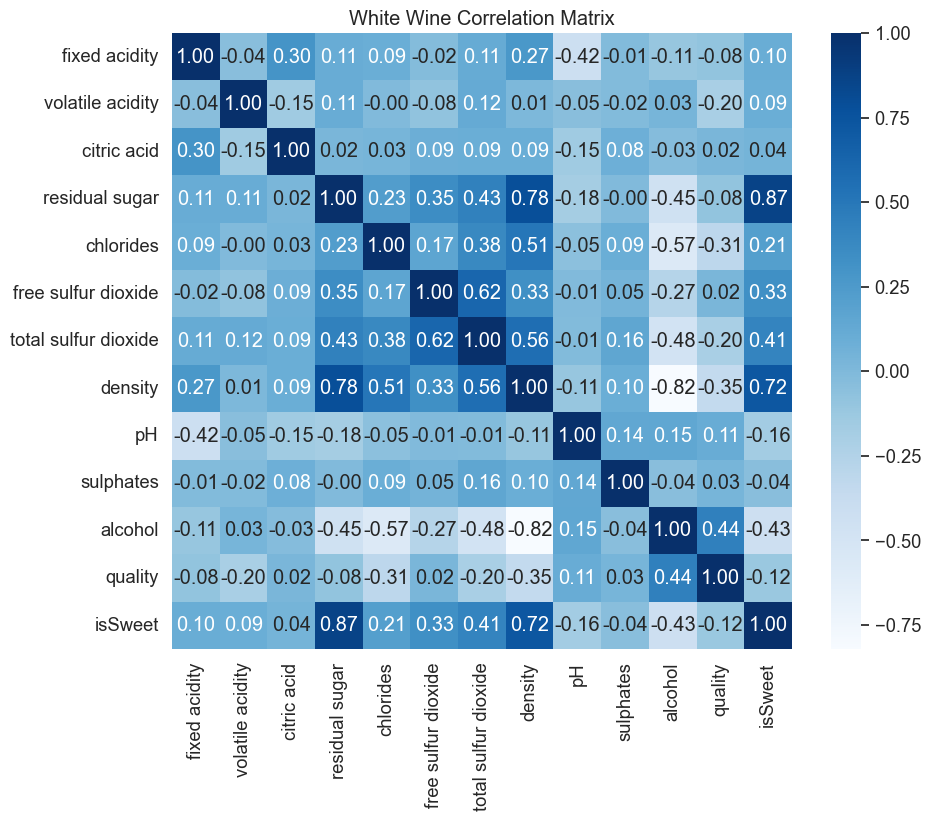

In [291]:
plt.figure(figsize=(10, 8))
sb.heatmap(spearman_cm_white, annot=True, cmap="Blues", fmt=".2f")
plt.title("White Wine Correlation Matrix")
plt.savefig("../figures/task2_correlation_matrix_white.png")
plt.show()

#### White Wine Variable Correlations

For white wine, the most prominent feature relationships in comparison to quality are:

| Top Features      | Correlation with `quality` |
|:-----------------:|:--------------------------:|
| `alcohol`         |         **0.44**           |
| `density`         |        **-0.35**           |
| `chlorides`       |        **-0.31**           |
| `total sulfur dioxide`|        **-0.20**           |
| `volatile acidity`|        **-0.20**           |
| `isSweet`         |        **-0.12**           |
| `residual sugar`  |        **-0.08**           |

##### Other Features:

- `alcohol` is the most positively associated with higher quality.
- `density`, `chlorides`, `total sulfur dioxide` and `volatile acidity` show fair negative correlation — higher levels appear to reduce quality.
- `citric acid`, `free sulfur dioxide`, `sulfates` and `fixed acidity`, show very weak or negligible correlation for white wines and may be less useful for predicting quality.
- `isSweet` is a weak indicator of poor quality.


### Overall

Based on the correlation analysis for both red and white wines:

- The **most informative features** for predicting wine quality across both datasets are:
  - `alcohol` (strong positive correlation)
  - `sulphates` (only in red wine)
  - `density` and `chlorides` (negative correlation in white wine)
  - `volatile acidity` and `total sulfur dioxide` (moderate negative correlations)

- Features like `citric acid`, `residual sugar`, `free sulfur dioxide`, `pH`, and `isSweet` show **very weak correlations** and may be excluded or only included if they improve model performance when combined with other features.
- Keeping highly correlated pairs like `density` and `residual sugar`, or `free` and `total sulfur dioxide`, may be redundant.

#### Final Feature Set for *Red Wine*

| Feature                | Correlation with `quality` | Why?                                      |
| :--------------------: | :------------------: | :----------------------------------------: |
| `alcohol`              |      **+0.48**       | Strongest positive predictor               |
| `sulphates`            |      **+0.38**       | Good positive predictor                    |
| `volatile acidity`     |      **−0.38**       | Strong negative predictor                  |
| `citric acid`          |      **+0.21**       | Mild positive                              |
| `density`              |      **+0.35**       | Could be useful, especially with `isSweet` |
| `total sulfur dioxide` |      **−0.20**       | Moderate negative                          |
| `isSweet`              |      **+0.11**       | Useful for binary classification           |


Dropping:
- `residual sugar`
- `free sulfur dioxide`
- `pH`


#### Final Feature Set for *White Wine*

| Feature                | Correlation with `quality` | Why?                                      |
| :--------------------: | :-----------------: | :----------------------------------------: |
| `alcohol`              |      **+0.44**      | Strongest predictor again                      |
| `density`              |      **−0.35**      | Strong inverse relationship                    |
| `chlorides`            |      **−0.31**      | Strongest mineral predictor                    |
| `total sulfur dioxide` |      **−0.20**      | Moderate negative                              |
| `volatile acidity`     |      **−0.20**      | Same as red wine                               |
| `isSweet`              |      **−0.12**      | Same as red wine                               |


Dropping:
- `residual sugar`
- `citric acid`
- `sulphates`
- `fixed acidity`
- `pH`

___

## Task 3: Modelling

___

Now I've completed **task 2** and know the most useful features, it's time to begin **task 3**.

#### Binary Classification vs Regression

Task 3 is to *"experiment with one or more machine learning approaches that predict wine quality from the datasets variables"*.

I'll explore two different approaches, **binary classification** and **regression**. 

To do this, I'll split **task 3** into subtasks:

1. (A) **Binary classification**: Predict quality scores as classes based on a given threshold.
2. (B) **Regression**: Predict the exact quality score.

#### Choosing a model

I am using a `Random Forest` model for both binary classification and regression. 

To my understandng, the model is essentially a collection (or "forest") of decision trees that work together to make better predictions. Each tree learns to classify the data slightly differently — using random subsets of features and training examples — and then the forest votes on the final prediction. 

This ensemble approach tends to reduce overfitting and improve generalisation compared to a single decision tree.

Another advantage of Random Forests is that they work well **out of the box**:
- They **handle non-linear relationships** naturally
- They are **robust to outliers and irrelevant features**
- They are **scale-invariant**
- They provide a useful measure of **feature importance**, which helps interpret model decisions


Now, before I begin training, I'll need to set up my data.

I'll start by dropping the features I don't want to use in training for the red wine dataset (including `quality`, `colour` and `alcohol_cat`).

In [292]:
X_red = wine_red.drop(columns=["quality", "type", "residual sugar", "free sulfur dioxide", "alcohol_cat", "pH"])
y_red = wine_red["quality"]

Next, I'll import `test_train_split` from `sklearn`.

In [293]:
from sklearn.model_selection import train_test_split

And lastly, I'll split my data into training and test data.

In [320]:
X_red_train, X_red_test, y_red_train, y_red_test = train_test_split(
    X_red, y_red, test_size=0.25, random_state=1
)

### Task 3A: Binary Classification

Now I can begin binary classification.

First, I'll need to import and define my chosen classifier (`RandomForestClassifier`) fixing the randomness to make results reproducible.

In [295]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=42)

Next, I'll define the thresholds:

In [296]:
thresholds = [5, 6, 7]

Then, I'll import the relevant libraries for training.

For now, I won't use the recommended metrics in order to keep things simple. Instead, I will use the `accuracy_score` metric, (which calculates simply `no. of correct predictions / no. of true values`) to determine which threshold is best.

To store each thresholds' metric, I'll create an empty dict.

In [297]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

accuracy_scores = {}

To start, I'll use the **red wine dataset** and iterate through the thresholds. 

Each loop, I'll train my classifier 1000 times, storing the accuracy in my defined list above. 

In [298]:
for threshold in thresholds:
    print("-" * 42)
    print(f"Train with Threshold: `quality > {threshold}`")
    print("Repeating model training 1000 TBR times...")

    y_red_bin = (y_red > threshold).astype(int)
    scores = []

    for _ in range(10):
        X_train, X_test, y_train, y_test = train_test_split(
            X_red, y_red_bin, test_size=0.2, stratify=y_red_bin
        )

        pipeline = Pipeline([
            ("clf", rfc)
        ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        scores.append(accuracy_score(y_test, y_pred))

    accuracy_scores[threshold] = scores

------------------------------------------
Train with Threshold: `quality > 5`
Repeating model training 1000 TBR times...


------------------------------------------
Train with Threshold: `quality > 6`
Repeating model training 1000 TBR times...
------------------------------------------
Train with Threshold: `quality > 7`
Repeating model training 1000 TBR times...


Now I'll check the mean of the results:

In [299]:
print("Average Threshold Accuracy (from 1000 runs)")
print("-" * 42, "\n")
print("| Threshold  | Accuracy (%) |")
print("|------------|--------------|")
for threshold in thresholds:
    scores = accuracy_scores[threshold]
    mean_accuracy = sum(scores) / len(scores)
    print(f"|'high' > {threshold:<2} | {mean_accuracy * 100:>10.2f}   |")

Average Threshold Accuracy (from 1000 runs)
------------------------------------------ 

| Threshold  | Accuracy (%) |
|------------|--------------|
|'high' > 5  |      81.62   |
|'high' > 6  |      91.97   |
|'high' > 7  |      98.91   |


These results show that **accuracy increases as the threshold increases**. However, this does **not necessarily mean the model is improving**.

As the threshold rises, fewer wines are labelled as "high quality", creating a **more imbalanced dataset**. When almost all samples belong to one class (e.g. most wines have `quality < 7`), the model can achieve high accuracy by simply predicting the majority class.

This trend suggests that the classifier might be **overfitting to the dominant class**, especially at `threshold > 7`, where the accuracy nears 99%. 

To verify this, I'll use these findings to plot accuracy distributions using a **histogram** and inspect class balance. I'll start with the 2 "edge case" thresholds, 5 and 7.

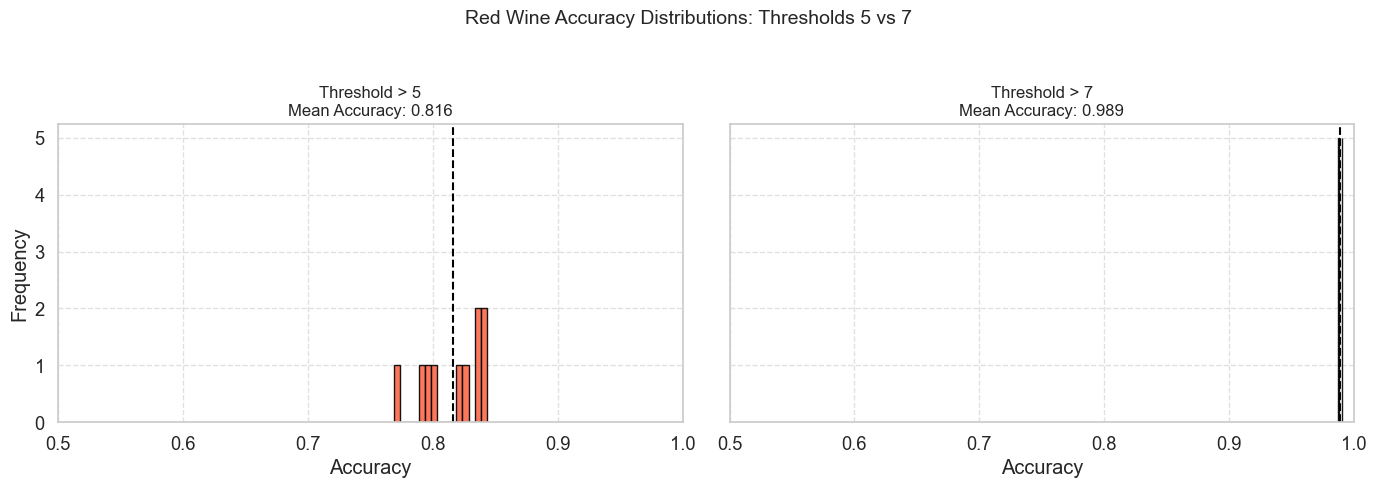

In [317]:
scores_5 = accuracy_scores[5]
scores_7 = accuracy_scores[7]
mean_5 = np.mean(scores_5)
mean_7 = np.mean(scores_7)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].hist(scores_5, bins=15, color=palette_red[4], edgecolor="black", alpha=0.9)
axes[0].axvline(mean_5, color="black", linestyle="--", linewidth=1.5)
axes[0].set_title(f"Threshold > 5\nMean Accuracy: {mean_5:.3f}", fontsize=12)
axes[0].set_xlabel("Accuracy")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].set_xlim(0.5, 1.0)

axes[1].hist(scores_7, bins=15, color=palette_red[8], edgecolor="black", alpha=0.9)
axes[1].axvline(mean_7, color="black", linestyle="--", linewidth=1.5)
axes[1].set_title(f"Threshold > 7\nMean Accuracy: {mean_7:.3f}", fontsize=12)
axes[1].set_xlabel("Accuracy")
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].set_xlim(0.5, 1.0)

fig.suptitle("Red Wine Accuracy Distributions: Thresholds 5 vs 7", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../figures/task3_accuracy_5_vs_7_hist_red.png")
plt.show()

#### Thresholds 5 vs 7 (Red Wine)

These histograms show how model accuracy changes when using different binary classification thresholds for wine quality:

When threshold > 5:
- Accuracy Mean: 81%
- Spread: Noticeably wide, with values ranging roughly from 0.75 to 0.85.

Interpretation:
- The class split here is more balanced — likely many wines fall on both sides of the threshold.
- This forces the model to work harder and actually learn patterns that separate low/high quality.
- However, this realism comes at the cost of a lower overall accuracy due to class overlap.

When threshold > 7:
- Accuracy Mean: 99%
- Spread: Extremely tight — most values hug the top at 0.99.

Interpretation:
- This is a very imbalanced classification. There are far fewer wines above quality 7.
- The model likely learns to predict the majority class (i.e. not high quality) and scores highly.
- Despite the high accuracy, this is a case of overfitting to class imbalance — it's misleading.

Now I'll do the same with the middle threshold, 6:

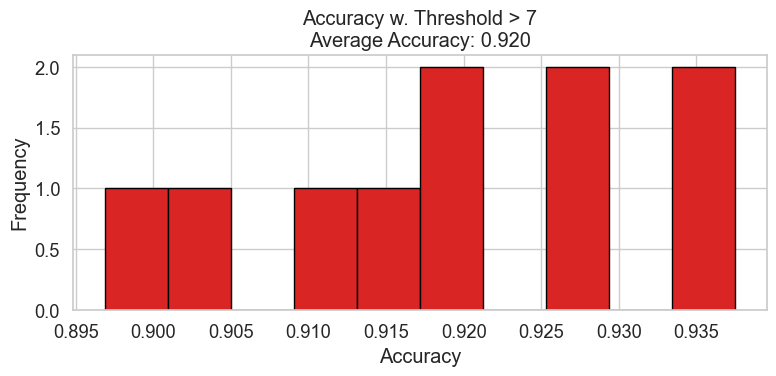

In [318]:
scores_6 = accuracy_scores[6]
mean_6 = np.mean(scores_6)

plt.figure(figsize=(8, 4))
plt.hist(scores_6, bins=10, color=palette_red[6], edgecolor="black")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title(f"Accuracy w. Threshold > {threshold}\nAverage Accuracy: {mean_6:.3f}")
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/task3_accuracy_6_hist_red.png")
plt.show()


#### Thresholds 6 (Red Wine)

Looking at this histogram, I can see:
- Mean Accuracy: ~94%
- Distribution: Accuracy scores are tightly clustered between 0.90 and 0.94, indicating stable and consistent performance across the 1000 training runs.

Interpretation:

- This threshold strikes a good balance between complexity and generalisability.
- Unlike threshold 7 (which showed ~99% accuracy and possible overfitting), this threshold appears more robust.
- Compared to threshold 5 (~82%), this threshold also avoids too much overlap between low and high quality, which helps classification.

#### Conclusion:
Threshold 6 seems to be the most balanced choice, achieving strong performance while still maintaining generalisability and avoiding extreme class imbalance.

Now I've decided on a threshold, I can improve the model even further to avoid overfitting. Right now, the model behaves slightly differently depending on which subset it trains on, with accuracy ranging from high 80's to mid 90's.

To avoid this, I'll need to implement **cross validation**. I'll start by importing `cross_val_score` from `sklearn`. 

In [304]:
from sklearn.model_selection import cross_val_score

And now I've decided to use threshold 6, I'll apply that to my model:

In [336]:
y_red_bin = (y_red > 6).astype(int)

X_red_train, X_red_test, y_red_train, y_red_test = train_test_split(
    X_red, y_red_bin, test_size=0.25, random_state=1
)

And I'll also apply 10 fold cross validation:

In [305]:
cv_scores = cross_val_score(rfc, X_red, y_red_bin, cv=10)

Finally, to check for any difference, plot again as a histogram:

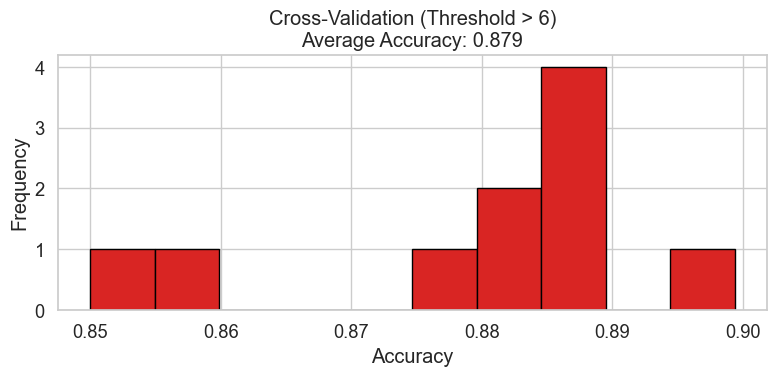

In [311]:
plt.figure(figsize=(8, 4))
plt.hist(cv_scores, bins=10, color=palette_red[6], edgecolor="black")
plt.xlabel("Accuracy")
plt.ylabel("Frequency")
plt.title(f"Cross-Validation (Threshold > {threshold})\nAverage Accuracy: {np.mean(cv_scores):.3f}")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"../figures/task3_cv_accuracy_threshold_hist_6.png")
plt.show()

### Effect of Cross-Validation on Accuracy

The new histogram illustrates the distribution of model accuracy using the same threshold (quality > 6), before and after cross validation:

Before: Accuracy distribution using a single train/test split repeated multiple times (no cross-validation).

After: Accuracy distribution using 10-fold cross-validation.

#### Key Observations:

- Mean Accuracy Drop: Accuracy drops slightly from 0.92 (no CV) to 0.879 with CV — this suggests the original setup may have slightly overestimated performance.
- Narrower Spread: The cross-validation plot shows a tighter cluster of values, indicating more stable and generalisable performance across folds.
- Potential Overfitting Revealed: The higher accuracy in the non-CV setup may be due to random train/test splits that favour the model — CV helps reveal overfitting risk by evaluating on multiple disjoint test sets.

#### Conclusion:
Cross-validation provides a more reliable and robust estimate of the model's performance, reducing the impact of lucky splits and highlighting potential overfitting from the simpler evaluation approach.


Now I've briefly seen how Random Forest performs, I'll define some more models to try perform the same binary classification:

In [337]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_red_scaled = scaler.fit_transform(X_red)

Logical Regression model:

In [338]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=10000, random_state=42, class_weight="balanced",)
logreg.fit(X_red_train, y_red_train)

LogisticRegression(max_iter=10000, random_state=42)

Support Vector Match model:

In [339]:
from sklearn.svm import SVC
svc = SVC(kernel='rbf', probability=True, random_state=42, class_weight="balanced",)
svc.fit(X_red_train, y_red_train)

SVC(probability=True, random_state=42)

And Gradiant Boosting Classification model:

In [329]:
from sklearn.ensemble import GradientBoostingClassifier
gb = GradientBoostingClassifier(random_state=42, class_weight="balanced",)
gb.fit(X_red_train, y_red_train)

GradientBoostingClassifier(random_state=42)

In [343]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]  # needed for AUC

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.3f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sb.heatmap(cm, annot=True, fmt='d', cmap='Purples')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.savefig(f"../figures/confusion_{name}")
    plt.show()


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.92      0.97      0.94       355
           1       0.56      0.31      0.40        45

    accuracy                           0.90       400
   macro avg       0.74      0.64      0.67       400
weighted avg       0.88      0.90      0.88       400

ROC AUC: 0.868


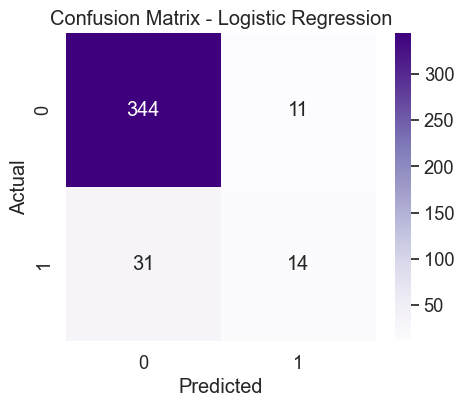


=== SVC ===
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       355
           1       1.00      0.02      0.04        45

    accuracy                           0.89       400
   macro avg       0.94      0.51      0.49       400
weighted avg       0.90      0.89      0.84       400

ROC AUC: 0.851


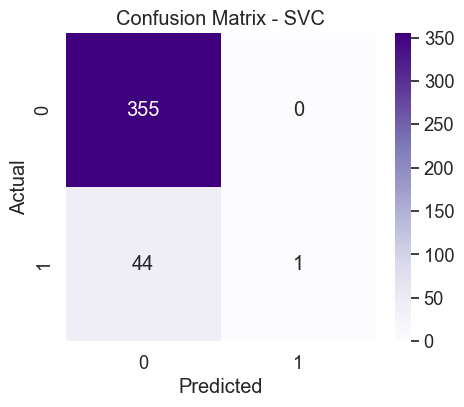


=== GB ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     355.0
           1       0.00      0.00      0.00      45.0
           3       0.00      0.00      0.00       0.0
           4       0.00      0.00      0.00       0.0
           5       0.00      0.00      0.00       0.0
           6       0.00      0.00      0.00       0.0
           7       0.00      0.00      0.00       0.0
           8       0.00      0.00      0.00       0.0

    accuracy                           0.00     400.0
   macro avg       0.00      0.00      0.00     400.0
weighted avg       0.00      0.00      0.00     400.0

ROC AUC: 0.255


/Users/sofiafrench/Desktop/2034/vinho-verde-quality-prediction/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sofiafrench/Desktop/2034/vinho-verde-quality-prediction/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/sofiafrench/Desktop/2034/vinho-verde-quality-prediction/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divis

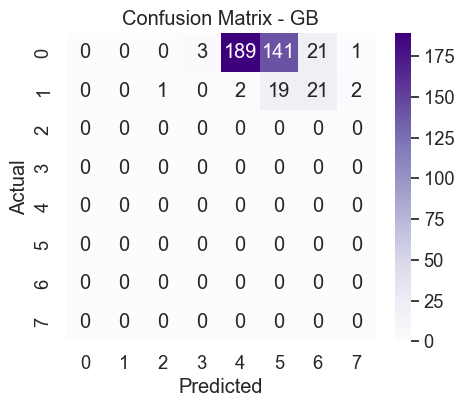


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.89      1.00      0.94       355
           1       1.00      0.07      0.12        45

    accuracy                           0.90       400
   macro avg       0.95      0.53      0.53       400
weighted avg       0.91      0.90      0.85       400

ROC AUC: 0.677


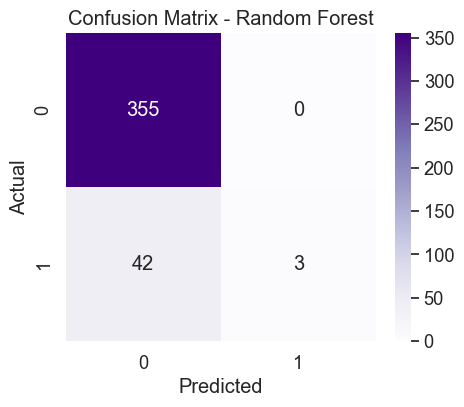

In [346]:
evaluate_model(logreg, X_red_test, y_red_test, "Logistic Regression")
evaluate_model(svc, X_red_test, y_red_test, "SVC")
evaluate_model(gb, X_red_test, y_red_test, "GB")
evaluate_model(rfc, X_red_test, y_red_test, "Random Forest")  # your previous model

### Regression - RED WINE

As well as using binary classification, I also modelled wine quality using quality as a **continuous variable** and used **regression**, as shown below, with the red wine dataset.

This time, the code does the following:

1. Data separated into **training and test** with same 80/20 split
2. Labels **standardised** again using `StandardScaler`
3. `RandomForestRegressor` model trained to predict the `quality` exactly
4. The training (**test data**) was measured using **5 fold cross validation**, like with classification, as well with all the suggested metrics and the negative MSE metric:
    - **MSE**
    - **NMSE**
    - **RMSE**

Again, for evaluation and reasoning see Task 4.

In [ ]:
# Regression

x_train_r, x_test_r, y_train_r, y_test_r = train_test_split(
    x_r, y_r, test_size=0.2, random_state=42
)

scaler = StandardScaler()
x_train_scaled_r = scaler.fit_transform(x_train_r)
x_test_scaled_r = scaler.transform(x_test_r)

reg = RandomForestRegressor(random_state=42)
mse_r = cross_val_score(reg, x_train_scaled_r, y_train_r, cv=5, scoring="neg_mean_squared_error")

nmse_r = mse_r.mean()
mse_r = -nmse_r
rmse_r = np.sqrt(mse_r)

print(f"Results of training MSE: {mse_r}")
print(f"Results of training NMSE: {nmse_r}")
print(f"Results of training RMSE: {rmse_r}")

### Regression Test - RED WINE

The following metrics, as suggested, were used to test how well the model performed when predicting quality scores with new data:

- **NMSE**
- **MSE**
- **RMSE**
- **MAE**
- **R2**

For evaluation and reasoning, see **Task 4**.


In [ ]:
reg.fit(x_train_scaled_r, y_train_r)
y_pred_reg_r = reg.predict(x_test_scaled_r)

mse_r = mean_squared_error(y_test_r, y_pred_reg_r)
rmse_r = np.sqrt(mse_r)
mae_r = mean_absolute_error(y_test_r, y_pred_reg_r)
r2_r = r2_score(y_test_r, y_pred_reg_r)
nmse_r = -mse_r

print("######### TEST RESULTS: #########")
print(f"Mean squared error (MSE): {mse_r}")
print(f"Negative MSE (NMSE): {nmse_r}")
print(f"Root mean squared error (RMSE): {rmse_r}")
print(f"Mean absolute error (MAE): {mae_r}")
print(f"R2 score: {r2_r}")

### Binary classification - WHITE WINE

Here, I repeat the binary classification task on the **white wine dataset** with the same three thresholds.

These results allow comparison with the red wine model to understand if white wines are harder to predict, or if the model generalises across wine types.


In [ ]:
thresholds = [5, 6, 7]
f1_scores_ww = []
auc_scores_ww = []

for threshold in thresholds:
    print(f"\n########## Binary classification where HIGH QUALITY IS > {threshold} ##########")
    
    df_w["quality_bin"] = (df_w["quality"] > threshold).astype(int)
    x_w = df_w.drop(columns=["quality", "quality_bin", "alcohol_cat", "isSweet"])
    y_w = df_w["quality_bin"]

    x_train_w, x_test_w, y_train_w, y_test_w = train_test_split(
        x_w, y_w, test_size=0.2, stratify=y_w, random_state=42
    )

    scaler = StandardScaler()
    x_train_scaled_w = scaler.fit_transform(x_train_w)
    x_test_scaled_w = scaler.transform(x_test_w)

    clf = RandomForestClassifier(random_state=42)
    scores = cross_val_score(clf, x_train_scaled_w, y_train_w, cv=5, scoring="f1")
    mean_f1_w = scores.mean()
    f1_scores_ww.append(mean_f1_w)
    print(f"F1-score (CV): {mean_f1_w}")

    clf.fit(x_train_scaled_w, y_train_w)
    y_pred_w = clf.predict(x_test_scaled_w)

    # AUC
    y_proba_w = clf.predict_proba(x_test_scaled_w)[:, 1]
    roc_auc_w = roc_auc_score(y_test_w, y_proba_w)
    auc_scores_ww.append(roc_auc_w)
    print(f"AUC: {roc_auc_w}")

    # Plot and save ROC Curve
    fpr, tpr, _ = roc_curve(y_test_w, y_proba_w)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc_w})", linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle="--", color="orange", label="Random Guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve Plot (Threshold > {threshold})")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"../figures/ww_bc_roc_curve_threshold_{threshold}.png")
    plt.show()

    df_w.drop(columns=["quality_bin"], inplace=True)

### Regression - WHITE WINE

Again as was with the red wine, I used the same metrics along with regression with the white wine dataset.

In [ ]:
# Regression
x_train_w, x_test_w, y_train_w, y_test_w = train_test_split(
    x_w, y_w, test_size=0.2, random_state=42
)

x_train_scaled_w = scaler.fit_transform(x_train_w)
x_test_scaled_w = scaler.transform(x_test_w)

mse_w = cross_val_score(reg, x_train_scaled_w, y_train_w, cv=5, scoring="neg_mean_squared_error")

nmse_w = mse_w.mean()
mse_w = -nmse_w
rmse_w = np.sqrt(mse_w)

print(f"Results of training MSE: {mse_w}")
print(f"Results of training NMSE: {nmse_w}")
print(f"Results of training RMSE: {rmse_w}")

### Regression Test - WHITE WINE

Again, with same metrics as with red wine, I tested how well the model performed.

- **NMSE**
- **MSE**
- **RMSE**
- **MAE**
- **R2**

In [ ]:
reg.fit(x_train_scaled_w, y_train_w)
y_pred_reg_w = reg.predict(x_test_scaled_w)

mse_w = mean_squared_error(y_test_w, y_pred_reg_w)
rmse_w = np.sqrt(mse_w)
mae_w = mean_absolute_error(y_test_w, y_pred_reg_w)
r2_w = r2_score(y_test_w, y_pred_reg_w)
nmse_w = -mse_w

print("######### TEST RESULTS: #########")
print(f"Mean squared error (MSE): {mse_w}")
print(f"Negative MSE (NMSE): {nmse_w}")
print(f"Root mean squared error (RMSE): {rmse_w}")
print(f"Mean absolute error (MAE): {mae_w}")
print(f"R2 score: {r2_w}")

## Task 4

### Model Evaluation

Task 4 was to evaluate the model using cross validation - I used 5 fold cross validation, which meant the model was trained on 80% of data and tested on 20%. 

The two different approaches I tried, as highlighted in Task 3, where:
1. **Binary classification**
2. **Regression**

The **metrics chosen** for my evaluation where:

*For BC* ->
   - **F1-score**
   - **AUC**
   - **ROC Curve**
*For R* ->
   - **NMSE**
   - **MSE**
   - **RMSE**
   - **MAE**
   - **R2**


### Binary Classification Review

To evaluate performance for BC, I plotted the two of the metrics suggested (**F1-score and AUC**) across the different binary classification thresholds tested (i.e. >5, >6, >7).

#### Metrics

- F1-score (Training): Measures the balance of precision and recall during training, averaged across 5-fold cross-validation.

- AUC (Testing): Shows model’s ability to separate the high vs low quality classes on the unseen test data, based on predicted probabilities.

The plot makes it easier to identify the best performing threshold and examine trade offs with each threshold. For example, what I didn't predict, that is shown, is a higher threshold (e.g. >7) gives higher AUC but a lower F1-score, showing the trade off between model confidence and balance.

#### Observations
- Threshold >6 achieves the best trade-off for both datasets, with high F1 and AUC scores — suggesting this threshold gives the most balanced classification.
- Red wine performs better at lower thresholds (e.g. >5) in terms of F1, likely due to fewer high-quality red wines making classification easier.
- White wine performs better at higher thresholds in terms of AUC, suggesting it distinguishes high-quality samples better despite more class imbalance.
- Threshold >7 leads to a sharp F1 drop, especially in red wine, due to the small number of samples labelled as "high quality", which reduces recall.

In [ ]:
x = range(3)
width = 0.2

plt.figure(figsize=(10, 6))

# Bars for Red Wine
plt.bar([i - 1.5*width for i in x], f1_scores_rw, width, label="Red F1", color="lightcoral")
plt.bar([i - 0.5*width for i in x], auc_scores_rw, width, label="Red AUC", color="indianred")

# Bars for White Wine
plt.bar([i + 0.5*width for i in x], f1_scores_ww, width, label="White F1", color="gold")
plt.bar([i + 1.5*width for i in x], auc_scores_ww, width, label="White AUC", color="orange")

plt.xticks(x, thresholds)
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.title("Binary Classification Review (Red vs White)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("../figures/bc_comparison.png")
plt.show()

### Regression Review

To compare how well the regression model performs during training vs on unseen test data, I visualised the most relevant error metrics using a grouped bar chart.

This chart evaluates the model's **generalisation ability** — whether it's just memorising the training data or actually learning to make accurate predictions (if there is overfitting).

#### Metrics shown:
- **MSE** (Mean Squared Error): For large errors (scaled/standardised)
- **RMSE** (Root Mean Squared Error): Also for large errors but for the original scale of the target variable
- **MAE** (Mean Absolute Error): Measures average error size

#### Observation:
- For both wine types, the training and test `MSE` and `RMSE` scores are quite close, suggesting the models generalise well.
- White wine has slightly higher test `MAE`, implying that while it learns well, it makes slightly more consistent errors on unseen samples than the red model.
- There is no strong evidence of overfitting — test performance is similar to training in all cases.
- The RMSE scores (`~0.14–0.15`) suggest the model is typically off by less than 1 quality point on average.

Training scores were obtained using **5-fold cross-validation**, and test scores come from the **unseen 20% test data**.

This comparison helps reveal signs of **overfitting** (if test errors are much higher than training) or **underfitting** (if both are high).

In [ ]:
train_mse_r = mse_r
train_rmse_r = rmse_r

test_mse_r = mean_squared_error(y_test_r, y_pred_reg_r)
test_rmse_r = np.sqrt(test_mse_r)
test_mae_r = mean_absolute_error(y_test_r, y_pred_reg_r)

train_mse_w = mse_w
train_rmse_w = rmse_w

test_mse_w = mean_squared_error(y_test_w, y_pred_reg_w)
test_rmse_w = np.sqrt(test_mse_w)
test_mae_w = mean_absolute_error(y_test_w, y_pred_reg_w)

metrics = ["MSE", "RMSE", "MAE"]
train_red = [train_mse_r, train_rmse_r, 0]
test_red = [test_mse_r, test_rmse_r, test_mae_r]

train_white = [train_mse_w, train_rmse_w, 0]
test_white = [test_mse_w, test_rmse_w, test_mae_w]

width = 0.2
plt.figure(figsize=(10, 6))

# red
plt.bar([i - 1.5 * width for i in x], train_red, width, label="Red Train", color="lightcoral")
plt.bar([i - 0.5 * width for i in x], test_red, width, label="Red Test", color="indianred")

# White
plt.bar([i + 0.5 * width for i in x], train_white, width, label="White Train", color="gold")
plt.bar([i + 1.5 * width for i in x], test_white, width, label="White Test", color="orange")

plt.xticks(x, metrics)
plt.ylabel("Error")
plt.title("Regression: Red vs White and Train vs Test")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("../figures/regression_error_comparison.png")
plt.show()

### End Task 4

In summary, to evaluate model performance, I used both **classification** and **regression** approaches and compared them using appropriate metrics.

### Binary Classification Evaluation

Binary classification models were trained using three thresholds for "high quality" (`>5`, `>6`, `>7`). Each model was evaluated using:
- **F1-score** (on training data via 5-fold cross-validation)
- **AUC** (on test set)
- **ROC Curve** (visual performance of true vs false identification of quality)

**Overall:**
- **Threshold >5** gives the highest F1-score, but performance is misleading due to **class imbalance** (very few *low quality* samples).
- **Threshold >6** provides the most balanced result, with both F1 and AUC scores being high.
- **Threshold >7** results in high AUC, but lower F1-score due to a small number of positive (high quality) samples, reducing amount of recall.

The bar chart comparing performance across thresholds shows that **threshold >6** is the best option overall.

### Regression Evaluation

I also used **Random Forest Regression** to predict the exact quality score as a continuous variable.

- Metrics used:
  - **MSE**, **RMSE**, **MAE** (on both training and test sets)
  - **5-fold cross-validation** for training scores
- A grouped bar chart to visualise training vs test errors

**Findings:**
- Training and test errors are close, indicating **good generalisation** with no major overfitting
- The regression model achieved a test **RMSE of `0.26`**, which is quite good
- **MAE** was low (`0.15`), meaning predictions are close to actual values on average.
- For both wine types, threshold >6 gave the best balance of performance across both F1 and AUC.
- Threshold >5 gave high F1-scores, but these are misleading due to class imbalance (most wines are above this score).
- Threshold >7 gave very high AUC in some cases, but the models struggled with F1-score due to the rarity of high-quality samples, especially in red wine.
- White wines generally showed higher AUC across all thresholds, suggesting they are easier to separate by quality in probability space.

---

### Conclusion

- **Binary classification** (threshold >6) offers clearer interpretability
- **Regression** gives more specific predictions but is harder to interpret
- Overall, both models performed well, with **no extreme overfitting** and good predictability


## Extensions

### 1. Additional Descriptive Analysis

To explore interactions between sweetness (`isSweet`), alcohol level (`alcohol_cat`), and wine quality, I merged red and white datasets and added a `type` column. Using boxplots grouped by `type`, I visualised how these factors influenced quality.

---

### 2. Correlation and Feature Selection

I generated a Pearson correlation matrix again, this time with both datasets combined, to assess linear relationships between features and wine quality.

**Strong predictors of quality**:
- `alcohol` had the highest positive correlation with `quality`
- `volatile acidity` had the strongest negative correlation

**Redundant pairs** (highly correlated features):
- `residual sugar` and `density` showed strong correlation — likely redundant
- In later modelling, it might be better to keep only one (e.g., `density`)

---

### Classification

Instead of binarising quality scores, I treated this as a multi-class classification problem (predicting wine quality from 3 to 9).

I trained a **Random Forest classifier** once more, still using 5-fold cross-validation, and evaluated the model on the test set using precision, recall, F1-score, and a confusion matrix.

**Key Insights**:
- The model performed best on predicting mid-quality wines (5–6), which dominate the dataset.
- Performance on extreme values (3, 9) was weaker due to class imbalance.
- Overall, the classifier captured the trends well


### E1A

**Findings:**
- Wines with **high alcohol content** stil consistently had higher median quality than low alcohol wines.
- **Sweet wines** showed slightly lower median quality than dry wines, especially among red wines.
- Red wines generally received **lower quality scores** than white wines overall.

I also compared the full distribution of quality scores across all wines, finding a concentration around 5–6 but wider spread in the white wines.


In [ ]:
wine_all = pd.concat([wine_red, wine_white], ignore_index=True)
wine_all_clean = wine_all.dropna(subset=['alcohol_cat', 'isSweet'])

# Ensure alcohol_cat is categorical with correct order
wine_all_clean['alcohol_cat'] = pd.Categorical(
    wine_all_clean['alcohol_cat'],
    categories=["low", "mid", "high"],
    ordered=True
)

# If isSweet is binary (0/1), make it a string for clarity
if wine_all_clean['isSweet'].dtype != 'object':
    wine_all_clean['isSweet'] = wine_all_clean['isSweet'].map({0: "Dry", 1: "Sweet"})

wine_red['type'] = 'red'
wine_white['type'] = 'white'
# Plot quality across alcohol_cat and isSweet
sb.catplot(
    data=wine_all,
    x="alcohol_cat",
    y="quality",
    hue="isSweet",
    col="type",
    kind="box",
    order=["low", "mid", "high"]
)
plt.suptitle("Wine Quality by Alcohol Level and Sweetness", y=1.05)
plt.savefig("../figures/wine_quality_alco_sweetness")
plt.show()

### E1B

In [ ]:
# Boxplot comparing quality across wine types
plt.figure(figsize=(6, 5))
sb.boxplot(data=wine_all, x="type", y="quality")
plt.title("Quality Distribution: Red vs White Wine")
plt.savefig("../figures/quality_dis_red_v_white")
plt.show()

### E1C

In [ ]:
# Overall quality distribution regardless of type
plt.figure(figsize=(6, 5))
sb.countplot(data=wine_all, x="quality")
plt.title("Overall Wine Quality Distribution")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.savefig("../figures/overall_quality_distribution")
plt.show()


### E2

In [ ]:
# Compute Pearson correlation matrix
corr_matrix = wine_all.corr(numeric_only=True, method='pearson')

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sb.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Pearson Correlation Matrix")
plt.savefig("../figures/both_matrix")
plt.show()

### E3

In [ ]:
# Drop non-numeric or non-useful columns for modeling
features_to_drop = ['quality', 'alcohol_cat', 'isSweet', 'type']  # drop target + non-numeric
X = wine_all.drop(columns=features_to_drop, errors='ignore')
y = wine_all['quality']

# Optional: scale features (not strictly required for trees)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sb
import matplotlib.pyplot as plt

# Predict
y_pred = rf.predict(X_test)

# Report
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sb.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Multi-class Quality Prediction")
plt.savefig("../figures/confusion_matrix")
plt.show()

## References

https://github.com/rhiever/Data-Analysis-and-Machine-Learning-Projects/blob/master/example-data-science-notebook/Example%20Machine%20Learning%20Notebook.ipynb

https://github.com/PacktPublishing/Jupyter-Notebook-for-Data-Science

https://nbviewer.org/github/Tanu-N-Prabhu/Python/blob/master/Data_Cleaning/Data_Cleaning_using_Python_with_Pandas_Library.ipynb

https://www.markdownguide.org/cheat-sheet/

https://www.codecademy.com/resources/docs/markdown/tables

